In [7]:
import argparse
import json
import logging
import os
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader

_DIR  = Path("/workspace/VTCM_PYTHON/inverse_model")
_ROOT = Path(_DIR).parent
sys.path.insert(0, str(_DIR))

In [8]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler(Path(_DIR) / "train.log", mode="a", encoding="utf-8"),
    ],
)
logger = logging.getLogger("train")


In [9]:
logger

<Logger train (INFO)>

In [10]:
def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description="PCNIO Training")
    p.add_argument("--epochs",       type=int,   default=100)
    p.add_argument("--batch_size",   type=int,   default=8)
    p.add_argument("--val_ratio",    type=float, default=0.15)
    p.add_argument("--window_size",  type=int,   default=256)
    p.add_argument("--stride",       type=int,   default=128,
                   help="Training uses overlapping windows (128), inference uses non-overlapping windows (256).")
    p.add_argument("--physics_mode", type=str,   default="frf",
                   choices=["none", "frf", "pinn", "both"])
    p.add_argument("--ckpt_dir",     type=str,   default=str(_DIR / "checkpoints"))
    p.add_argument("--resume",       action="store_true",
                   help="Resume training from ckpt_dir/best_model.pt")
    p.add_argument("--train_data_dir",     type=str,   default=str(_ROOT / "results" / "pino_train_dataset"),\
                   help="automatically and recursively search for simulation_result.npz")
    p.add_argument("--test_data_dir",     type=str,   default=str(_ROOT / "results" / "pino_test_dataset"),\
                   help="automatically and recursively search for simulation_result.npz")
    p.add_argument("--preproc_dir",  type=str,   default=str(_ROOT / "data" / "preprocessed"),
                   help="preprocessing cache directory")
    p.add_argument("--log_every",    type=int,   default=5)
    return p.parse_args()

In [16]:
npz_path = '../results/pino_train_dataset/高速客车-随机不平顺-vehicle-standard-20260324_072013/files/simulation_result.npz'
data  = np.load(npz_path, allow_pickle=True)

In [20]:
A_raw = data["A"]
A_raw.shape

(70000, 35)

In [21]:
data["idx_car_start"]
A_raw

array(0)

In [3]:
import h5py
import numpy as np
from pathlib import Path

HDF5_DIR = Path("../datasets/VTCM_inverse")

def load_split(split: str = "train", verbose: bool = True):
    """
    读取逆向训练 HDF5 数据集的某个 split。

    返回字典，key 对应 HDF5 中各 dataset：
      y              [N, T, n_sensors]     传感器加速度（归一化）
      u              [N, L, n_irr_dofs]    轨道不平顺（归一化）
      c              [N, n_cond]           条件向量
      x_query        [N, L]               空间坐标 [0,1]
      vx             [N, 1]               运行速度 m/s
      natural_freqs  [N, n_modal]
      damping_ratios [N, n_modal]
      window_start   [N, 1]
      window_end     [N, 1]
      source_file    [N]                  原始路径字符串（含中文）
    """
    h5_path = HDF5_DIR / f"{split}.hdf5"
    assert h5_path.exists(), f"找不到文件: {h5_path}"

    arrays = {}
    with h5py.File(h5_path, "r") as f:
        if verbose:
            print(f"── {split}.hdf5 根属性 ──")
            for k, v in f.attrs.items():
                print(f"  {k}: {v}")
            print()

        for key in f.keys():
            ds = f[key]
            if ds.dtype.kind in ("O", "S"):
                # 路径可能含中文，需按 utf-8 解码
                raw = ds[:]
                arrays[key] = np.array(
                    [v.decode("utf-8") if isinstance(v, bytes) else str(v) for v in raw]
                )
            else:
                arrays[key] = ds[:]

    if verbose:
        print(f"── {split} split 各 dataset shape ──")
        for k, v in arrays.items():
            shape = v.shape if hasattr(v, "shape") else f"len={len(v)}"
            print(f"  {k:20s}: {shape}")
        print()

    return arrays

# ── 加载归一化参数 ────────────────────────────────────────────────────────
norm = np.load(HDF5_DIR / "norm_stats.npz")
print("── norm_stats ──")
for k in norm.files:
    print(f"  {k}: shape={norm[k].shape}  mean={norm[k].mean():.4f}")
print()

# ── 读取各 split ─────────────────────────────────────────────────────────
train_data = load_split("train_full_seq")
val_data   = load_split("validation_full_seq")
test_data  = load_split("test_full_seq")

print(f"train  样本数: {train_data['y'].shape[0]}")
print(f"val    样本数: {val_data['y'].shape[0]}")
print(f"test   样本数: {test_data['y'].shape[0]}")


── norm_stats ──
  y_mean: shape=(3,)  mean=0.0001
  y_std: shape=(3,)  mean=0.1127
  u_mean: shape=(1,)  mean=-0.0000
  u_std: shape=(1,)  mean=0.0009

── train_full_seq.hdf5 根属性 ──
  format: VTCM_inverse_full_seq_v1
  n_irr_dofs: 1
  n_modal: 8
  n_sensors: 3
  sensor_local_dofs: 1,6,11
  skip_initial_seconds: 2.0
  spatial_len: 256
  stride: 128
  target_freq_hz: 200
  window_size: 256

── train_full_seq split 各 dataset shape ──
  c                   : (160, 17)
  damping_ratios      : (160, 8)
  natural_freqs       : (160, 8)
  seq_lengths         : (160,)
  source_file         : (160,)
  u                   : (160, 1000, 1)
  vx                  : (160, 1)
  x_query             : (160, 1000)
  y                   : (160, 1000, 3)

── validation_full_seq.hdf5 根属性 ──
  format: VTCM_inverse_full_seq_v1
  n_irr_dofs: 1
  n_modal: 8
  n_sensors: 3
  sensor_local_dofs: 1,6,11
  skip_initial_seconds: 2.0
  spatial_len: 256
  stride: 128
  target_freq_hz: 200
  window_size: 256

── valida

u_denorm shape: (160, 1000, 1)
y_denorm shape: (160, 1000, 3)


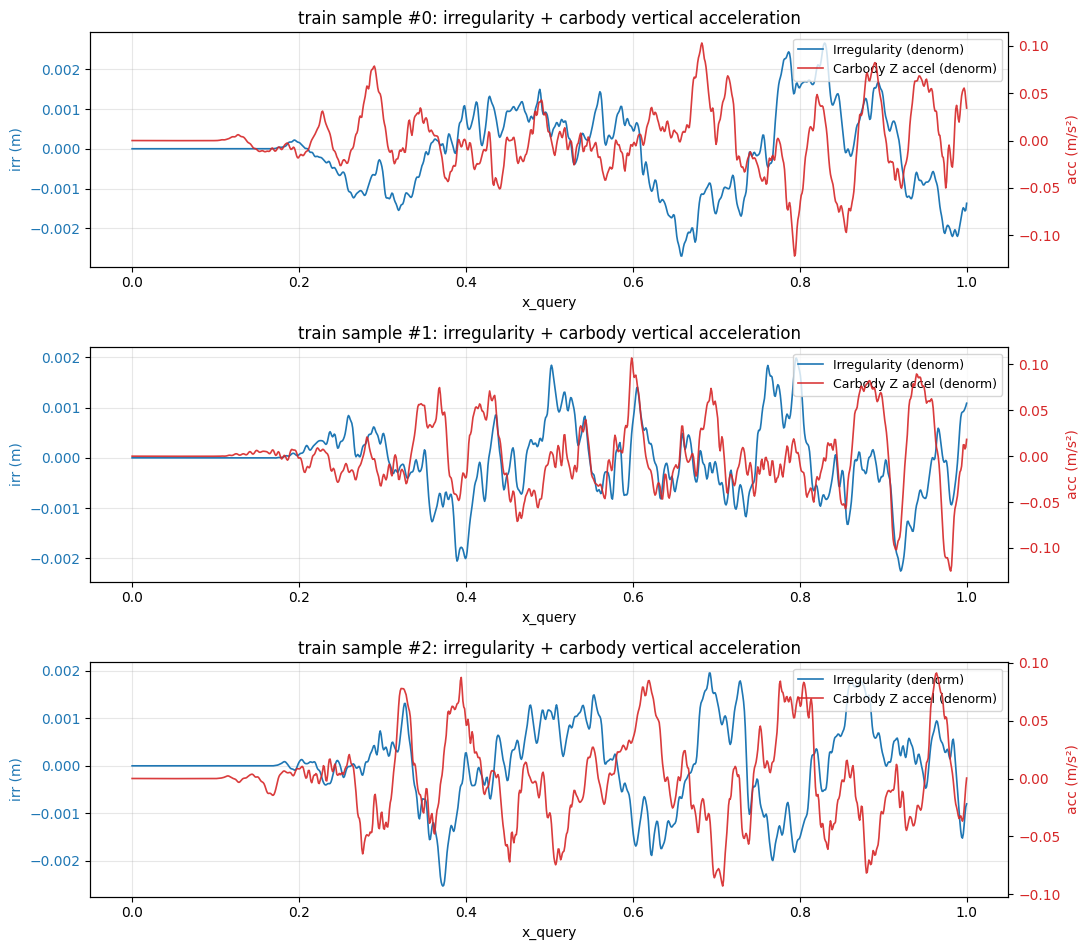

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# u: [N, L, n_irr_dofs]（归一化）
# y: [N, T, n_sensors]（归一化），默认第0通道为车体垂向加速度
u_norm = train_data["u"]
y_norm = train_data["y"]

# 反归一化：不平顺 u
u_mean = norm["u_mean"].reshape(1, 1, -1)   # [1,1,n_irr]
u_std  = norm["u_std"].reshape(1, 1, -1)    # [1,1,n_irr]
u_denorm = u_norm * u_std + u_mean           # [N,L,n_irr]

# 反归一化：加速度 y
y_mean = norm["y_mean"].reshape(1, 1, -1)    # [1,1,n_sensors]
y_std  = norm["y_std"].reshape(1, 1, -1)     # [1,1,n_sensors]
y_denorm = y_norm * y_std + y_mean            # [N,T,n_sensors]

print("u_denorm shape:", u_denorm.shape)
print("y_denorm shape:", y_denorm.shape)

# 画前3个样本：左轴不平顺，右轴车体垂向加速度（双y轴）
n_plot = min(3, u_denorm.shape[0], y_denorm.shape[0])
fig, axes = plt.subplots(n_plot, 1, figsize=(11, 3.2 * n_plot), sharex=False)
if n_plot == 1:
    axes = [axes]

for i in range(n_plot):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # 不平顺 x 轴
    x_u = train_data["x_query"][i] if "x_query" in train_data else np.arange(u_denorm.shape[1])
    irr = u_denorm[i, :, 0]   # 第1个不平顺通道（通常垂向）

    # 车体垂向加速度（第0个传感器通道）
    acc = y_denorm[i, :, 0]

    # 若长度不同，将加速度插值到不平顺横轴，便于同图对比
    if len(acc) != len(x_u):
        x_acc_src = np.linspace(float(x_u[0]), float(x_u[-1]), len(acc))
        acc_plot = np.interp(x_u, x_acc_src, acc)
    else:
        acc_plot = acc

    l1 = ax1.plot(x_u, irr, color="tab:blue", lw=1.2, label="Irregularity (denorm)")
    l2 = ax2.plot(x_u, acc_plot, color="tab:red", lw=1.2, alpha=0.9, label="Carbody Z accel (denorm)")

    ax1.set_ylabel("irr (m)", color="tab:blue")
    ax2.set_ylabel("acc (m/s²)", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f"train sample #{i}: irregularity + carbody vertical acceleration")

    # 合并图例
    lines = l1 + l2
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper right", fontsize=9)

    ax1.set_xlabel("x_query" if "x_query" in train_data else "index")

plt.tight_layout()
plt.show()
